In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

#Uber/Lyft brand colors
UBER_COLOR = '#000000'
LYFT_COLOR = '#FF00BF'
BEFORE_COLOR = '#2ecc71'
AFTER_COLOR = '#e74c3c'
print("libraries loaded")

libraries loaded


In [6]:
#initialize BigQuery Client
client = bigquery.Client(project='uber-lyft-earnings-analysis')

#test connection
query = """
SELECT COUNT(*) as total_rows
FROM `uber-lyft-earnings-analysis.tlc_trips.Trips`
"""

result = client.query(query).to_dataframe()
print("Connection successful!")
print("Total rows:", result['total_rows'][0])

/opt/anaconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Connection successful!
Total rows: 2984690


## Before/After Comparison

In [7]:
#Loading query1 results, before/after comparison
query_overall = """
SELECT
period,
ROUND(AVG(base_passenger_fare), 2) AS avg_passenger_fare,
  ROUND(AVG(driver_pay), 2) AS avg_driver_pay,
  ROUND(AVG(driver_take_rate), 3) AS avg_take_rate,
  ROUND(AVG(cbd_congestion_fee), 2) AS avg_congestion_fee
FROM `uber-lyft-earnings-analysis.tlc_trips.Trips`
GROUP BY period
ORDER BY period DESC
"""
df_overall = client.query(query_overall).to_dataframe()
print(df_overall)

   period  avg_passenger_fare  avg_driver_pay  avg_take_rate  \
0  before               26.79           20.76          0.792   
1   after               25.38           19.16          0.753   

   avg_congestion_fee  
0                 0.0  
1                 0.5  


/opt/anaconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [12]:
#separate before and after
before = df_overall[df_overall['period'] == 'before'].iloc[0]
after = df_overall[df_overall['period'] == 'after'].iloc[0]

#defining metrics and values
metrics = ['Avg Passenger Fare', 'Avg Driver Pay', 'Avg Take Rate (%)']
before_values = [before['avg_passenger_fare'], before['avg_driver_pay'], before['avg_take_rate'] * 100]
after_values = [after['avg_passenger_fare'], after['avg_driver_pay'], after['avg_take_rate'] * 100]

print("Before:", before_values)
print("After:", after_values)

Before: [26.79, 20.76, 79.2]
After: [25.38, 19.16, 75.3]


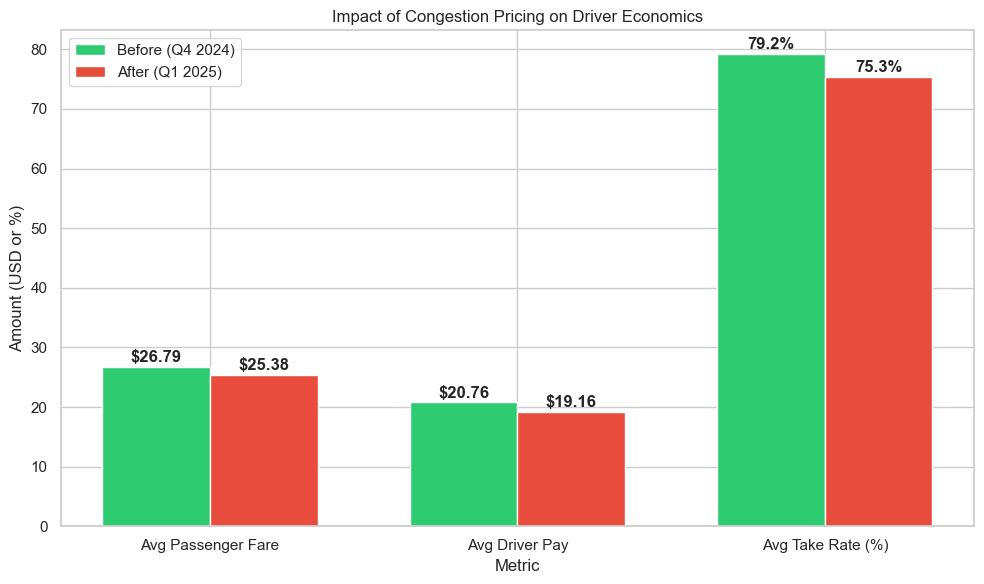

In [18]:
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, before_values, width, label='Before (Q4 2024)', color=BEFORE_COLOR)
bars2 = ax.bar(x + width/2, after_values, width, label='After (Q1 2025)', color=AFTER_COLOR)

#add data labels on bars 
for i, bar in enumerate(bars1):
    val = bar.get_height()
    label = f'{val:.1f}%' if i == 2 else f'${val:.2f}'
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, 
            label, ha='center', va='bottom', fontweight='bold')

for i, bar in enumerate(bars2):
    val = bar.get_height()
    label = f'{val:.1f}%' if i == 2 else f'${val:.2f}'
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            label, ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Metric')
ax.set_ylabel('Amount (USD or %)')
ax.set_title('Impact of Congestion Pricing on Driver Economics')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
plt.tight_layout()
plt.show()

## Earnings per Boroughs Visualized through a Heatmap

In [20]:
#Borough Earnings Heatmap

query_borough = """
SELECT 
    T1.period,
    T2.Borough,
    ROUND(AVG(earnings_per_mile), 3) AS avg_earnings_per_mile,
    ROUND(AVG(driver_take_rate), 3) AS avg_take_rate,
    ROUND(AVG(driver_pay), 2) AS avg_driver_pay
FROM `uber-lyft-earnings-analysis.tlc_trips.Trips` T1
JOIN `uber-lyft-earnings-analysis.tlc_trips.taxi_zones` T2
ON T1.PULocationID = T2.LocationID
WHERE T2.Borough NOT IN ('N/A', 'EWR')
GROUP BY T1.period, T2.Borough
ORDER BY T1.period DESC, avg_earnings_per_mile DESC
"""

df_borough = client.query(query_borough).to_dataframe()
print(df_borough)

   period        Borough  avg_earnings_per_mile  avg_take_rate  avg_driver_pay
0  before      Manhattan                  6.542          0.751           22.86
1  before       Brooklyn                  5.444          0.808           18.27
2  before          Bronx                  5.008          0.850           16.74
3  before         Queens                  4.595          0.814           22.55
4  before  Staten Island                  4.278          0.815           18.31
5   after      Manhattan                  5.804          0.701           20.28
6   after       Brooklyn                  5.343          0.773           17.19
7   after          Bronx                  4.888          0.805           16.14
8   after         Queens                  4.452          0.785           21.63
9   after  Staten Island                  4.237          0.785           17.36


/opt/anaconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


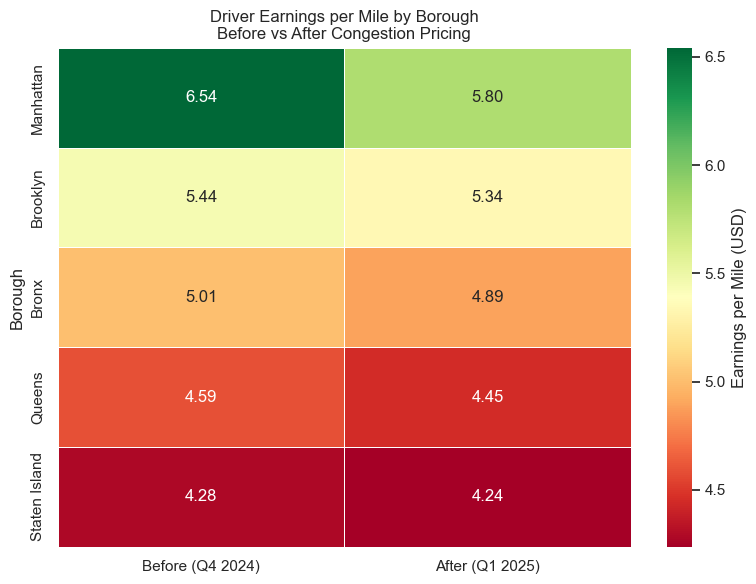

In [21]:
#Pivoting data for heatmap
heatmap_data = df_borough.pivot(index='Borough', columns='period', values='avg_earnings_per_mile')

#Reorder columns 
heatmap_data = heatmap_data[['before', 'after']]
heatmap_data.columns = ['Before (Q4 2024)', 'After (Q1 2025)']

#Sort by before earnings
heatmap_data = heatmap_data.sort_values('Before (Q4 2024)', ascending=False)

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            linewidths=0.5,
            cbar_kws={'label': 'Earnings per Mile (USD)'})

plt.title('Driver Earnings per Mile by Borough\nBefore vs After Congestion Pricing')
plt.xlabel('')
plt.ylabel('Borough')
plt.tight_layout()
plt.show()

## Uber vs Lyft Comparison

In [22]:
#Uber vs Lyft Comparison Chart 
query_platform = """
SELECT 
    period,
    platform,
    ROUND(AVG(base_passenger_fare), 2) AS avg_passenger_fare,
    ROUND(AVG(driver_pay), 2) AS avg_driver_pay,
    ROUND(AVG(driver_take_rate) * 100, 2) AS avg_take_rate_pct
FROM `uber-lyft-earnings-analysis.tlc_trips.Trips`
GROUP BY period, platform
ORDER BY platform, period DESC
"""

df_platform = client.query(query_platform).to_dataframe()
print(df_platform)

   period platform  avg_passenger_fare  avg_driver_pay  avg_take_rate_pct
0  before     Lyft               25.76           19.62              75.32
1   after     Lyft               23.71           18.46              75.90
2  before     Uber               27.12           21.12              80.49
3   after     Uber               25.98           19.41              75.03


/opt/anaconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


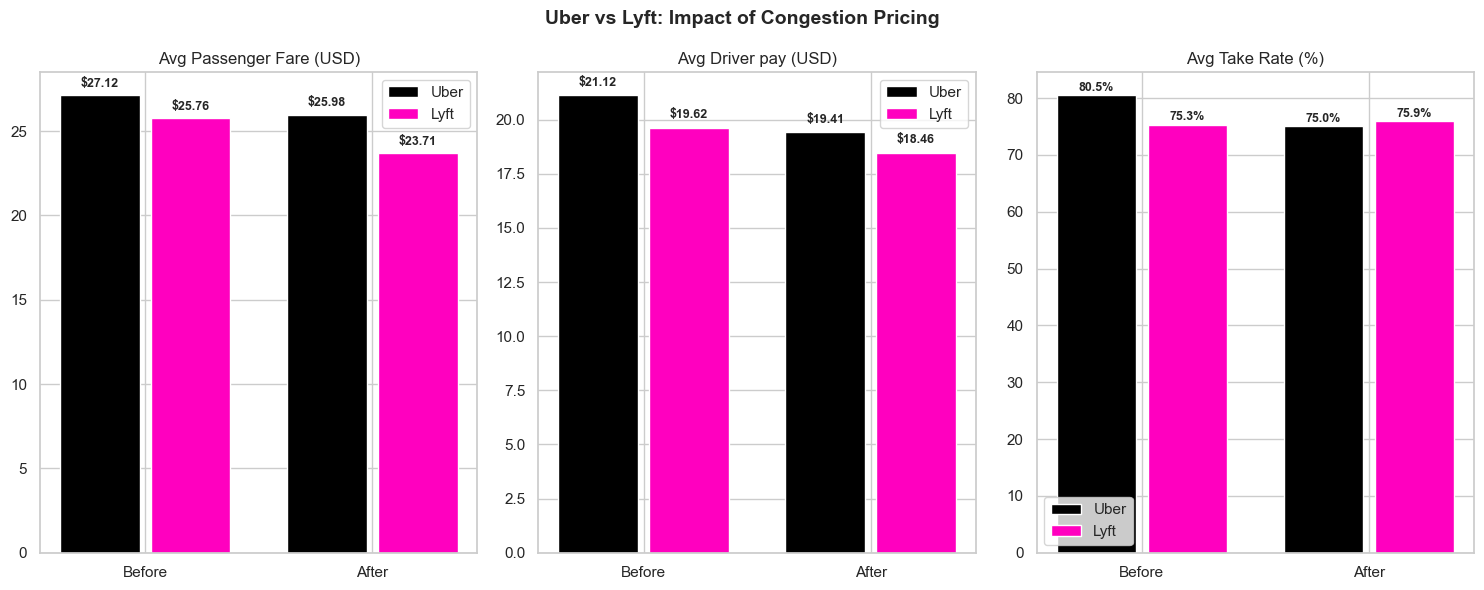

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

metrics = ['avg_passenger_fare', 'avg_driver_pay', 'avg_take_rate_pct']
titles = ['Avg Passenger Fare (USD)', 'Avg Driver pay (USD)', 'Avg Take Rate (%)']
formats = ['${:.2f}', '${:.2f}', '{:.1f}%']

for idx, (metric, title, fmt) in enumerate(zip(metrics, titles, formats)):
    ax = axes[idx]

    uber_before = df_platform[(df_platform['platform']=='Uber') & (df_platform['period']=='before')][metric].values[0]
    uber_after = df_platform[(df_platform['platform']=='Uber') & (df_platform['period']=='after')][metric].values[0]
    lyft_before = df_platform[(df_platform['platform']=='Lyft') & (df_platform['period']=='before')][metric].values[0]
    lyft_after = df_platform[(df_platform['platform']=='Lyft') & (df_platform['period']=='after')][metric].values[0]

    x = np.arange(2)
    bars1 = ax.bar(x - 0.2, [uber_before, uber_after], 0.35, label='Uber', color=UBER_COLOR)
    bars2 = ax.bar(x + 0.2, [lyft_before, lyft_after], 0.35, label='Lyft', color=LYFT_COLOR)

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(['Before', 'After'])
    ax.legend()

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                fmt.format(bar.get_height()), ha='center', va='bottom', fontsize=9, fontweight='bold')

    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                fmt.format(bar.get_height()), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Uber vs Lyft: Impact of Congestion Pricing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Take Rate per Borough Comparison

In [25]:
#Borough take rate comparison

query_take_rate = """
SELECT
    T1.period,
    T2.Borough,
    ROUND(AVG(driver_take_rate) * 100, 2) AS avg_take_rate_pct
FROM `uber-lyft-earnings-analysis.tlc_trips.Trips` T1
JOIN `uber-lyft-earnings-analysis.tlc_trips.taxi_zones` T2
ON T1.PULocationID = T2.LocationID
WHERE T2.Borough NOT IN ('N/A', 'EWR')
GROUP BY T1.period, T2.Borough
ORDER BY T1.period DESC, avg_take_rate_pct DESC
"""

df_take_rate = client.query(query_take_rate).to_dataframe()
print(df_take_rate)

/opt/anaconda3/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


   period        Borough  avg_take_rate_pct
0  before          Bronx              85.00
1  before  Staten Island              81.47
2  before         Queens              81.40
3  before       Brooklyn              80.76
4  before      Manhattan              75.07
5   after          Bronx              80.53
6   after         Queens              78.50
7   after  Staten Island              78.48
8   after       Brooklyn              77.27
9   after      Manhattan              70.12


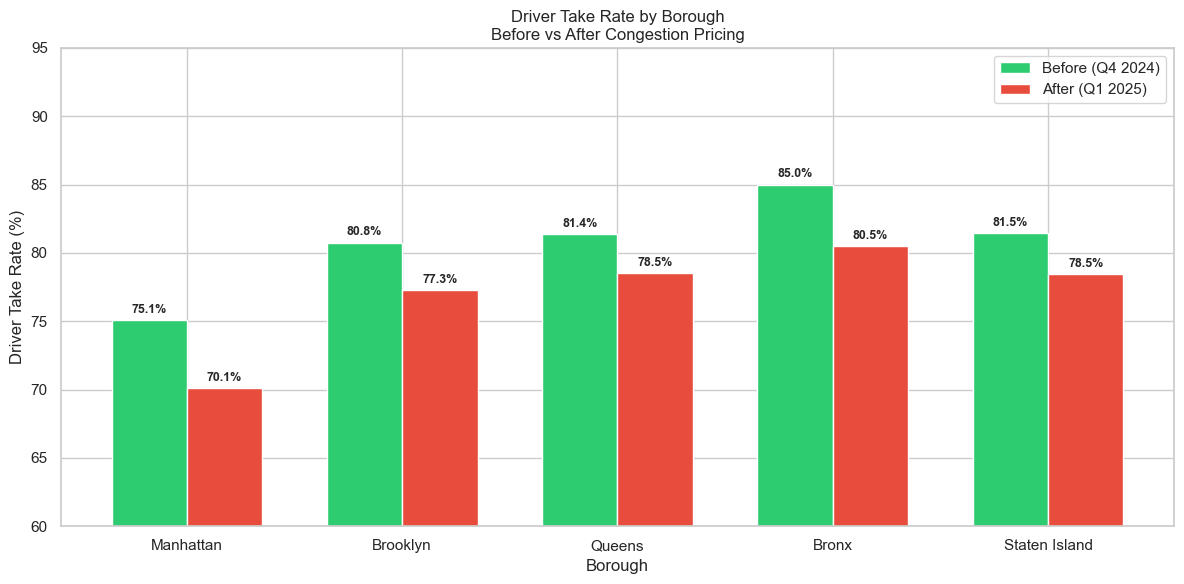

In [28]:
boroughs = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']

before_rates = df_take_rate[df_take_rate['period'] == 'before'].set_index('Borough').loc[boroughs]['avg_take_rate_pct']
after_rates = df_take_rate[df_take_rate['period'] == 'after'].set_index('Borough').loc[boroughs]['avg_take_rate_pct']

x = np.arange(len(boroughs))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, before_rates, width, label='Before (Q4 2024)', color=BEFORE_COLOR)
bars2 = ax.bar(x + width/2, after_rates, width, label='After (Q1 2025)', color=AFTER_COLOR)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xlabel('Borough')
ax.set_ylabel('Driver Take Rate (%)')
ax.set_title('Driver Take Rate by Borough\nBefore vs After Congestion Pricing')
ax.set_xticks(x)
ax.set_xticklabels(boroughs)
ax.set_ylim(60, 95)
ax.legend()
plt.tight_layout()
plt.show()
